# 1 · Words to next-token probabilities

**Question.** Can the embedding → concatenate → hidden-layer MLP from the name generator learn a real word-level next-token task?

This notebook follows the implementation-first rhythm of [Karpathy's *makemore* sequence](https://karpathy.ai/zero-to-hero.html) and the inspectable style of [Nipun Batra's names notebook](https://nipunbatra.github.io/ml-teaching/notebooks/names.html), but changes the tokens from characters to lowercase words and punctuation. It aligns with [Attention and language · Part I](https://nipunbatra.github.io/attention/part1.html).

**Learning path**

```text
story → word/punctuation tokens → integer IDs → learned rows
      → concatenate a fixed window → ReLU hidden layer
      → one logit per vocabulary item → cross-entropy → next-token probabilities
```

We split whole stories *before* making overlapping windows. Only training stories fit the vocabulary. The test split stays untouched until the architecture and training settings below are fixed.


In [1]:
from pathlib import Path
import json, math, os, sys, time

HERE = Path.cwd()
if not (HERE / "wordlm.py").exists():
    matches = list(Path.cwd().rglob("word-level-next-token/wordlm.py"))
    if not matches:
        raise FileNotFoundError("Run this notebook from its word-level-next-token directory.")
    HERE = matches[0].parent
sys.path.insert(0, str(HERE))

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from wordlm import *

SEED = 11
seed_everything(SEED)
DEVICE = resolve_device(os.getenv("WORDLM_DEVICE", "auto"))
plt.style.use("seaborn-v0_8-whitegrid")
print(f"torch={torch.__version__}  device={DEVICE}")


torch=2.14.0  device=mps


## The complete route

The two maps below are our table of contents. Training sends an observed target
to the loss. Inference appends a chosen token and leaves the model parameters fixed.
Later cells highlight the same map without rearranging it.

`B` = batch size, `w` = context slots, `d` = embedding width, `h` = hidden width,
`C` = vocabulary size. In generation, `B=1`. Open Notebook 5 for the window-by-window
trace, individual model operations, optimizer step and checkpoint inference.


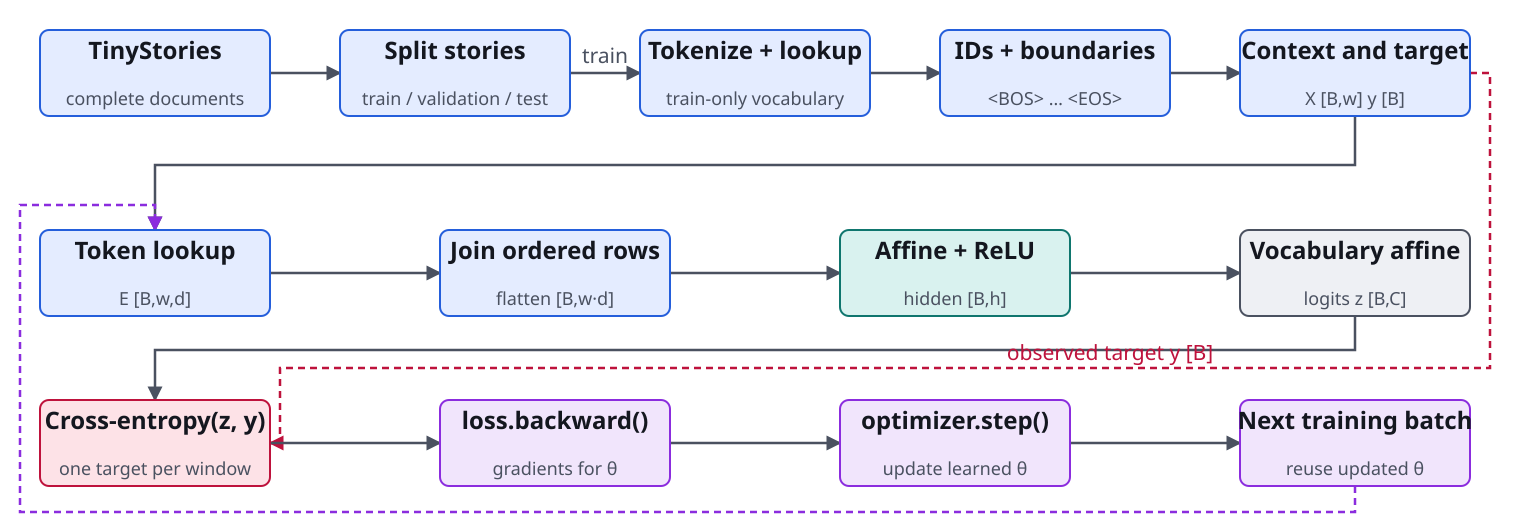

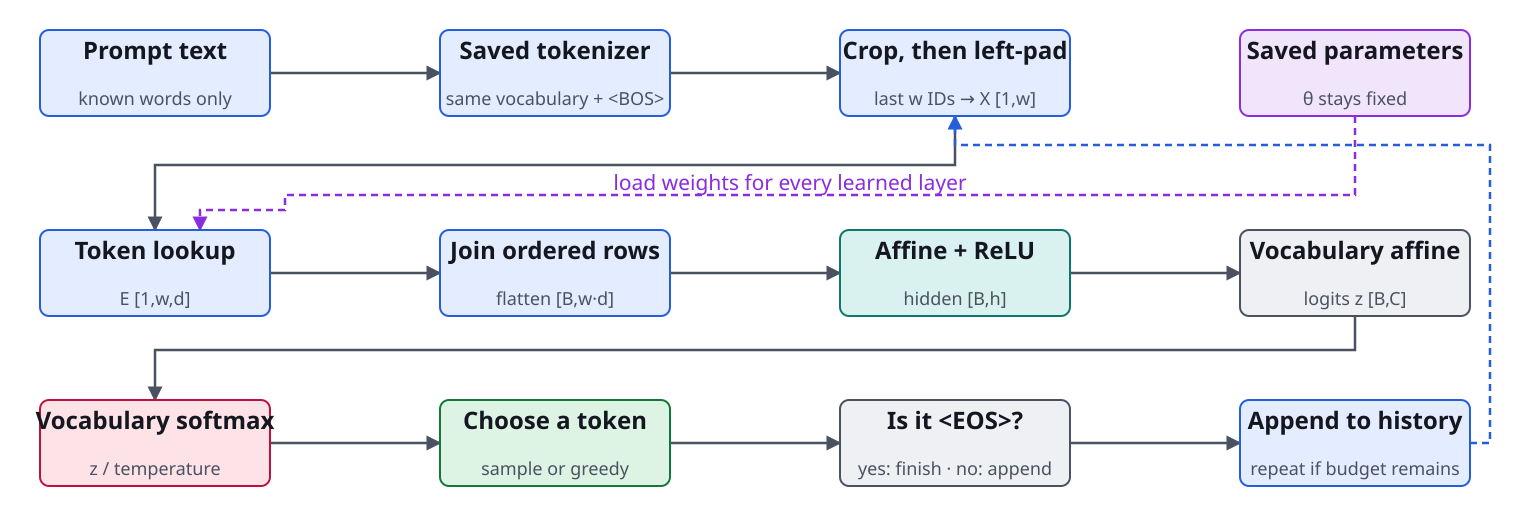

In [2]:
from pipeline_maps import show_pipeline
show_pipeline('mlp', 'training')
show_pipeline('mlp', 'inference')


## 1. A bounded, auditable corpus

[TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) contains synthetic short stories generated with GPT-3.5 and GPT-4 and is listed under **CDLA-Sharing-1.0**. The upstream repository is pinned to commit `f54c09f…`. The quick profile fetches 480 deterministic source rows through Hugging Face's documented row API—no dataset script or pickle is executed.

Exact duplicates are removed first. A stable hash then assigns each complete story to train/validation/test (80/10/10 in expectation), so no window can cross a story or split boundary.


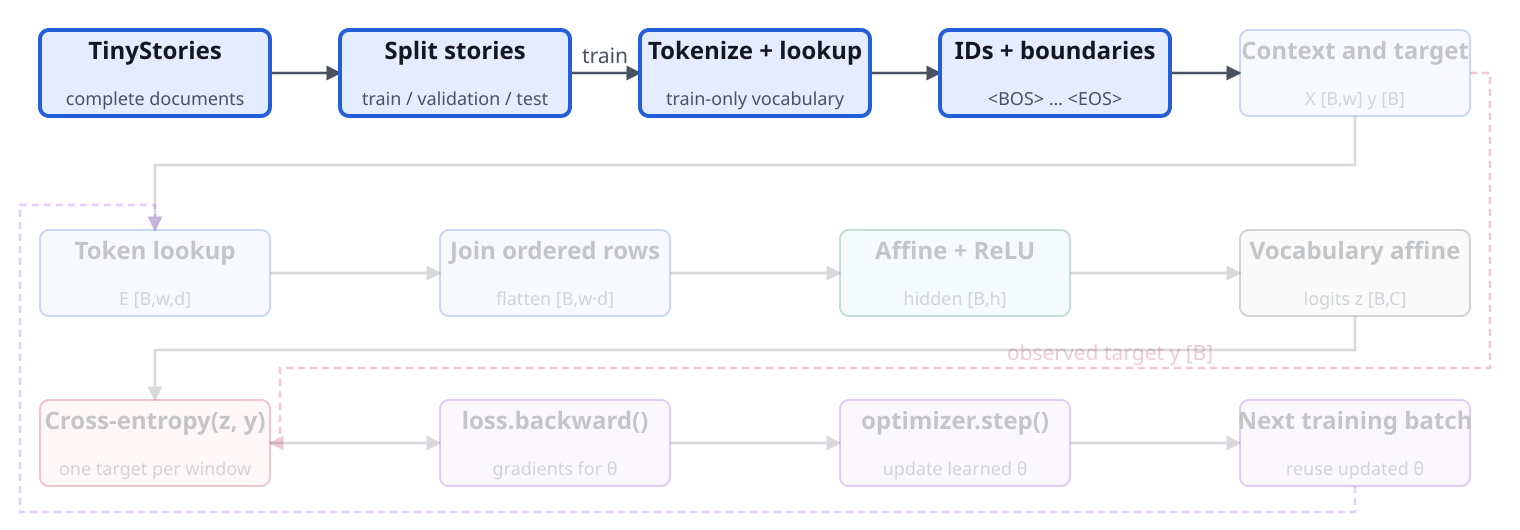

In [3]:
show_pipeline('mlp', 'training', ('stories', 'split', 'tokenize', 'ids'))


In [4]:
PROFILE = os.getenv("WORDLM_PROFILE", "smoke")
DATA_ROOT = HERE / "work" / "data"
corpus = build_corpus(DATA_ROOT, PROFILE)

print("source revision:", corpus.manifest["dataset_revision"])
print("raw subset SHA-256:", corpus.manifest["raw_sha256"])
print("documents:", corpus.audit["documents"])
print("duplicates removed before split:", corpus.audit["duplicates_removed_before_split"])
print("document overlap audit:", corpus.audit["document_overlap"])
print("vocabulary size:", len(corpus.vocab.itos), "(fit on train only)")
for split in ["validation", "test"]:
    print(f"{split} OOV rate: {corpus.audit['oov'][split]['rate']:.2%}")
assert not any(corpus.audit["document_overlap"].values())


source revision: f54c09fd23315a6f9c86f9dc80f725de7d8f9c64
raw subset SHA-256: bc144eecd2cbb87e0d99fcb69255eb89f435bbd6c7024791fa25d27dea7be8f3
documents: {'train': 371, 'validation': 57, 'test': 52}
duplicates removed before split: 0
document overlap audit: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}
vocabulary size: 1500 (fit on train only)
validation OOV rate: 6.83%
test OOV rate: 6.61%


**Interpretation.** Held-out words that miss the train-only vocabulary become `<UNK>`. This is a real limitation of word tokenization, not evidence leakage to be repaired by peeking at validation or test text.

We normalize Unicode with NFKC, lowercase it, collapse whitespace, keep contractions such as `don't` together, and make punctuation separate tokens. The four special tokens have separate jobs:

- `<PAD>` left-pads short contexts; `<BOS>` starts each story.
- `<EOS>` is a learnable stopping target; `<UNK>` represents held-out or rare words.


In [5]:
example = "Lily's little cat, Max, didn't sleep!"
pieces = tokenize(example)
rebuilt = detokenize(pieces)
print("text:       ", example)
print("tokens:     ", pieces)
print("detokenized:", rebuilt)
assert tokenize(rebuilt) == pieces

first_story = corpus.stories["train"][0]
print("\nOne story preview (first 32 tokens only):")
print(first_story.doc_id, first_story.tokens[:32])


text:        Lily's little cat, Max, didn't sleep!
tokens:      ["lily's", 'little', 'cat', ',', 'max', ',', "didn't", 'sleep', '!']
detokenized: lily's little cat, max, didn't sleep!

One story preview (first 32 tokens only):
005d5f421b8e63c7 ['one', 'day', ',', 'a', 'little', 'girl', 'named', 'lucy', 'was', 'walking', 'down', 'the', 'street', '.', 'she', 'smiled', 'when', 'she', 'saw', 'a', 'shop', '.', 'she', 'ran', 'up', 'to', 'the', 'shop', 'and', 'looked', 'through', 'the']


## 2. Context–target examples

With context length $w=8$, every observed token (and the final `<EOS>`) is one target. The context is the preceding eight IDs, left-padded inside that story only.


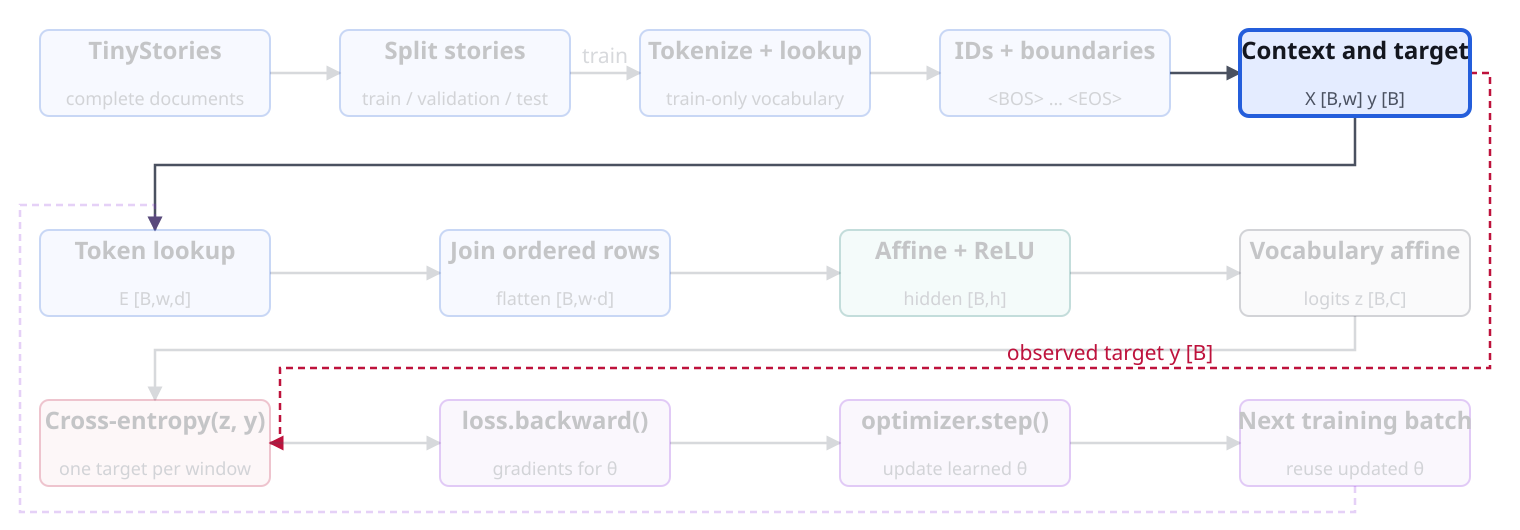

In [6]:
show_pipeline('mlp', 'training', ('windows',))


In [7]:
CONTEXT_LEN = 8
windows = make_all_windows(corpus, CONTEXT_LEN)
X_train, y_train, train_doc_ids = windows["train"]
X_val, y_val, _ = windows["validation"]
X_test, y_test, _ = windows["test"]

def show_pair(row):
    context = corpus.vocab.decode_ids(X_train[row], skip_special=False)
    target = corpus.vocab.itos[int(y_train[row])]
    return " ".join(context), target, train_doc_ids[row]

for row in range(6):
    context, target, doc_id = show_pair(row)
    print(f"{context:70s} → {target:12s}  doc={doc_id}")
print("\nshapes:", tuple(X_train.shape), tuple(y_train.shape))
assert all(len(set(ids)) == 1 for ids in [train_doc_ids[: min(6, len(train_doc_ids))]])


<PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <BOS>                        → one           doc=005d5f421b8e63c7
<PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <BOS> one                          → day           doc=005d5f421b8e63c7
<PAD> <PAD> <PAD> <PAD> <PAD> <BOS> one day                            → ,             doc=005d5f421b8e63c7
<PAD> <PAD> <PAD> <PAD> <BOS> one day ,                                → a             doc=005d5f421b8e63c7
<PAD> <PAD> <PAD> <BOS> one day , a                                    → little        doc=005d5f421b8e63c7
<PAD> <PAD> <BOS> one day , a little                                   → girl          doc=005d5f421b8e63c7

shapes: (70193, 8) (70193,)


## 3. The fixed-window MLP

```text
IDs [B,w] → lookup E[IDs] [B,w,d] → flatten [B,w·d]
          → affine + ReLU [B,h] → affine [B,|V|]
```

In row-vector notation,

$$a_0=[e_1,\ldots,e_w],\qquad a_1=\operatorname{ReLU}(a_0W_1+b_1),\qquad z=a_1W_2+b_2.$$

`cross_entropy(z, y)` applies log-softmax stably and scores the observed target. The embedding table, both weight matrices, and both biases are learned together.


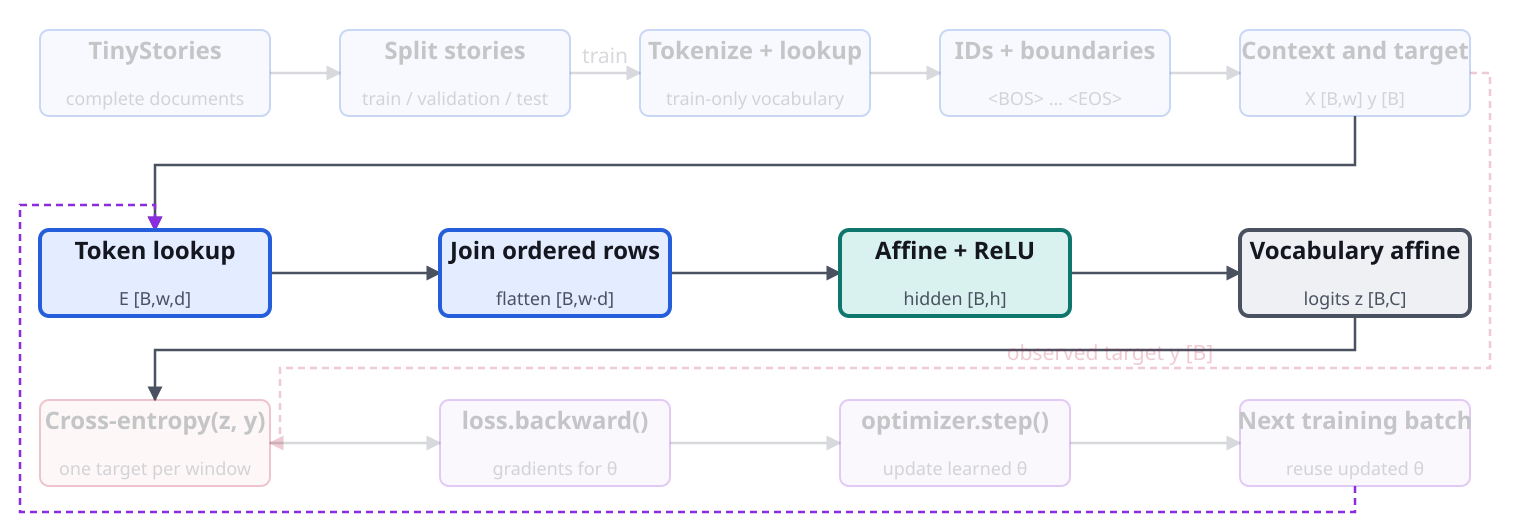

In [8]:
show_pipeline('mlp', 'training', ('embedding', 'flatten', 'hidden', 'logits'))


In [9]:
class WordMLP(nn.Module):
    def __init__(self, vocab_size, context_len, d_embed=32, hidden=128, pad_id=0):
        super().__init__()
        self.context_len, self.d_embed = context_len, d_embed
        self.token_embedding = nn.Embedding(vocab_size, d_embed, padding_idx=pad_id)
        self.hidden_layer = nn.Linear(context_len * d_embed, hidden)
        self.vocab_head = nn.Linear(hidden, vocab_size)

    def forward(self, context_ids):
        embedded = self.token_embedding(context_ids)                 # [B,w,d]
        a0 = embedded.reshape(context_ids.shape[0], -1)              # [B,w*d]
        a1 = F.relu(self.hidden_layer(a0))                            # [B,h]
        logits = self.vocab_head(a1)                                 # [B,|V|]
        return logits

seed_everything(SEED)
model = WordMLP(len(corpus.vocab.itos), CONTEXT_LEN, 32, 128, corpus.vocab.pad_id)
logits = model(X_train[:4])
print("lookup:", tuple(model.token_embedding(X_train[:4]).shape))
print("logits:", tuple(logits.shape), "parameters:", f"{count_parameters(model):,}")
print("initial cross-entropy:", float(F.cross_entropy(logits, y_train[:4])))
assert logits.shape == (4, len(corpus.vocab.itos))


lookup: (4, 8, 32)
logits: (4, 1500) parameters: 274,396
initial cross-entropy: 7.431373596191406


/var/folders/1x/wmgn24mn1bbd2vgbqlk98tbc0000gn/T/ipykernel_22127/3165965846.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  print("initial cross-entropy:", float(F.cross_entropy(logits, y_train[:4])))


**Interpretation.** The first layer sees $w d$ inputs. Doubling the context length doubles both that activation width and the $wd\times h$ first weight matrix. Notebook 2 measures this trade-off.


## 4. Debug before training: overfit 16 examples

A small network should memorize a tiny batch. Failure here usually means a target shift, shape, optimizer, or gradient bug—not insufficient data.


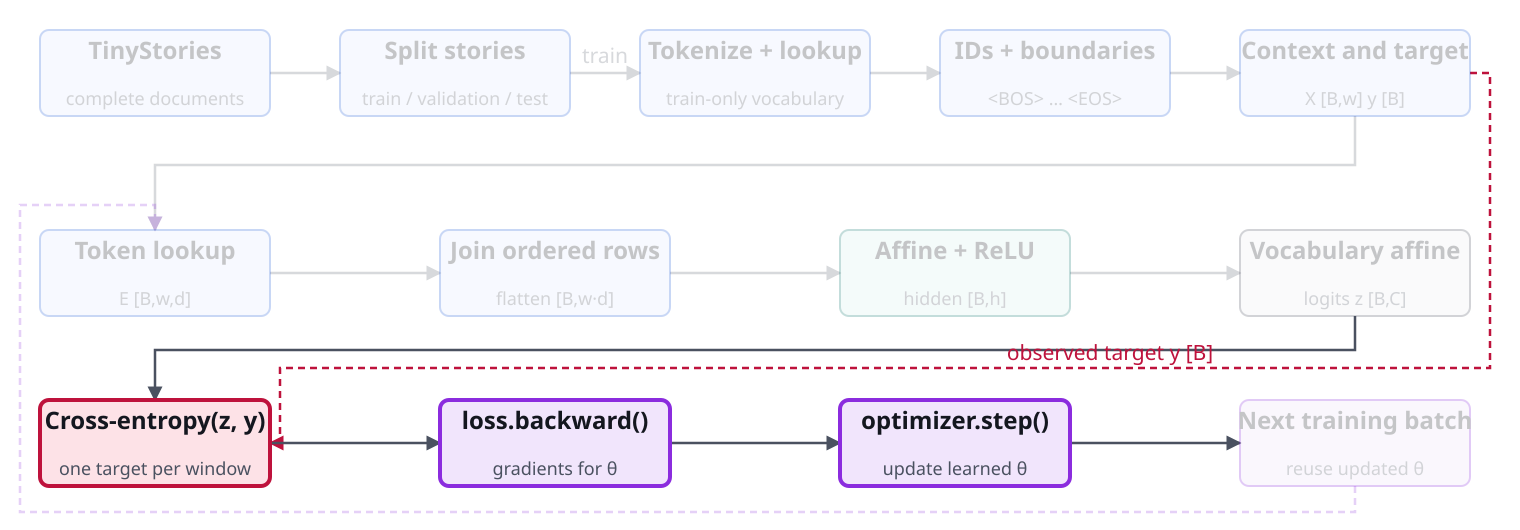

In [10]:
show_pipeline('mlp', 'training', ('loss', 'backward', 'optimizer'))


In [11]:
seed_everything(23)
debug_model = WordMLP(len(corpus.vocab.itos), CONTEXT_LEN, 24, 96, corpus.vocab.pad_id)
before, after = tiny_batch_overfit(debug_model, X_train, y_train, device=DEVICE, steps=180)
print(f"tiny-batch loss: {before:.3f} → {after:.5f}")
assert after < min(0.15, before / 10)


tiny-batch loss: 7.352 → 0.00000


## 5. Train, validate, then touch test once

AdamW and gradient clipping are practical training ingredients rather than new language-model architecture. The smoke profile is intentionally small; the measured DGX-profile comparison appears in Notebook 4.


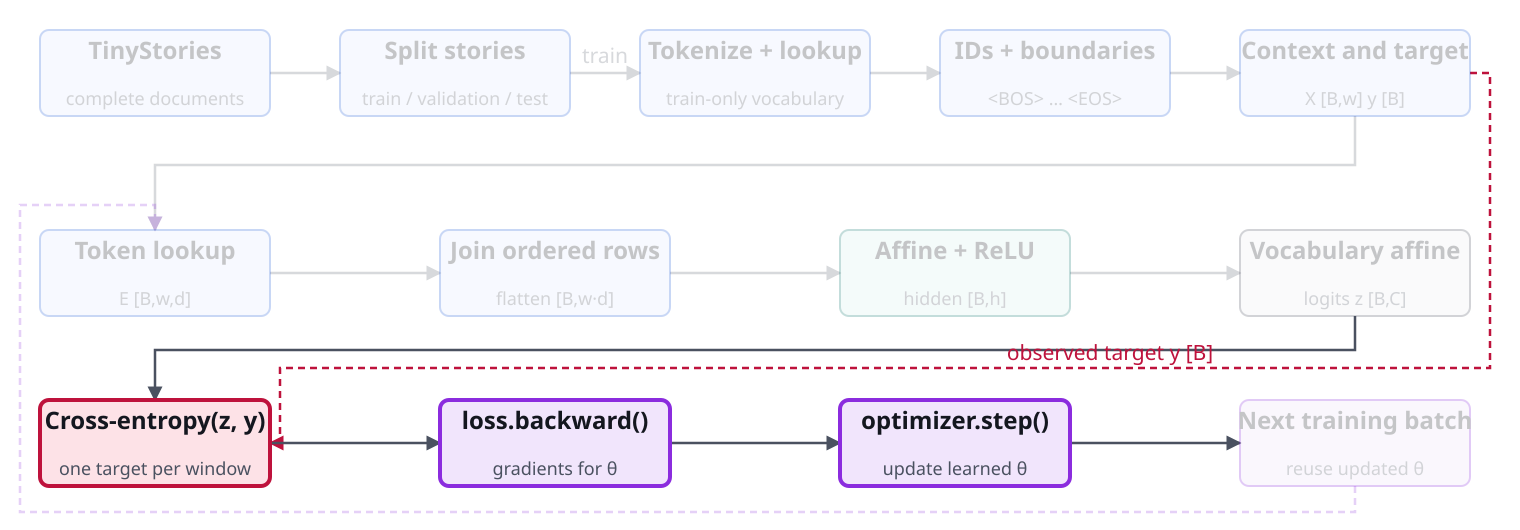

In [12]:
show_pipeline('mlp', 'training', ('loss', 'backward', 'optimizer'))


In [13]:
seed_everything(SEED)
model = WordMLP(len(corpus.vocab.itos), CONTEXT_LEN, 32, 128, corpus.vocab.pad_id)
config = TrainConfig(
    steps=300, batch_size=256, learning_rate=3e-3, weight_decay=1e-4,
    seed=SEED, eval_every=50, eval_examples=20_000,
)
result, _ = train_model(model, X_train, y_train, X_val, y_val, config, device=DEVICE)
test_loss = evaluate_loss(model, X_test, y_test, device=DEVICE)
print(f"validation CE={result['validation_loss']:.3f}, PPL={math.exp(result['validation_loss']):.2f}")
print(f"test CE={test_loss:.3f}, PPL={math.exp(test_loss):.2f}  (first and only test use)")
print(f"tokens seen={result['tokens_seen']:,}, runtime={result['runtime_seconds']:.1f}s")


validation CE=4.232, PPL=68.88
test CE=4.340, PPL=76.68  (first and only test use)
tokens seen=76,800, runtime=2.2s


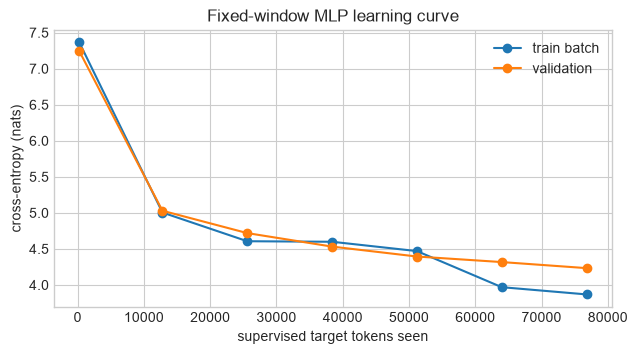

In [14]:
trace = result["trace"]
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot([p["tokens_seen"] for p in trace], [p["train_batch_loss"] for p in trace], "o-", label="train batch")
ax.plot([p["tokens_seen"] for p in trace], [p["validation_loss"] for p in trace], "o-", label="validation")
ax.set(xlabel="supervised target tokens seen", ylabel="cross-entropy (nats)", title="Fixed-window MLP learning curve")
ax.legend(); plt.show()


The validation curve is the tuning signal. Perplexity is $\exp(\text{cross-entropy})$ and is comparable only when tokenizer, vocabulary, targets, and reduction are held fixed.

## 6. Generate with fixed parameters

Temperature changes the sampling distribution $p=\operatorname{softmax}(z/\tau)$; it does not retrain the model. Lower temperature is sharper, higher temperature is more varied.


### The inference loop on the same map

Reuse the saved tokenizer and vocabulary. Crop long history to the last `w`
tokens, left-pad a shorter prefix, predict, choose a token and append it.
Stop on `<EOS>` or the token limit. This implementation recomputes the window;
it does not use a KV cache. No target, backward pass or optimizer step is involved.


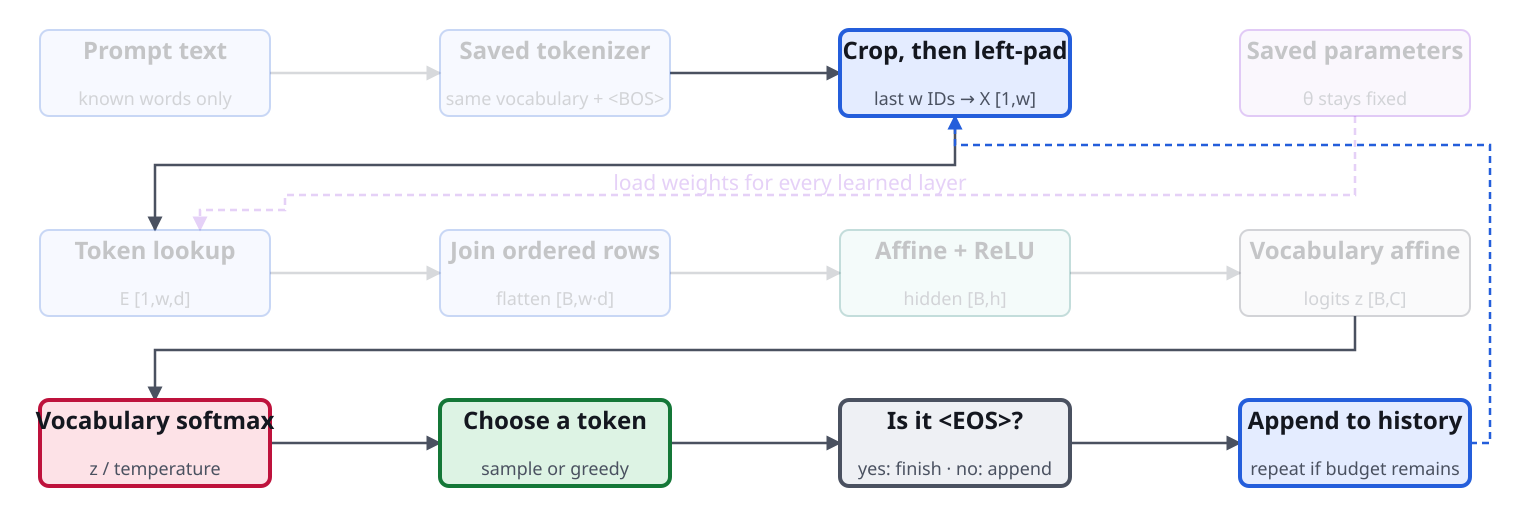

In [15]:
show_pipeline('mlp', 'inference', ('windows','probabilities','choose','append','stop'))


In [16]:
for temperature in [0.7, 1.0, 1.3]:
    print(f"T={temperature:.1f}:", generate_text(
        model, corpus.vocab, "once upon a time", context_len=CONTEXT_LEN,
        max_new_tokens=45, temperature=temperature, seed=4, device=DEVICE,
    ))


T=0.7: once upon a time, there was a little girl named lily. she loved to play with her he saw see the car of them hopped the girl of them and timmy was an. one day, she was walking and jill felt lily, she saw
T=1.0: once upon a time, the two a 3, the light became together. they doing a bright he saw a around called of a hopped mess they had them playing. suddenly an the cake. she had a mother and so felt lily, now will
T=1.3: once upon a time, the two a still stable by in a girl named brothers doing a bright he saw a around fire of lost hopped be roll spirit way playing happy. especially the cake. she frog better to and so played cheered, now will


**What this notebook supports.** A word-level learned-embedding MLP can be trained end-to-end and sampled. Its outputs on the smoke profile may still be repetitive or locally plausible rather than coherent; that is an observed limitation, not a formatting failure. The next notebook gives this baseline a controlled tuning pass before attention is compared with it.
